# Model Inference Analysis — Shared XGBoost and GAM Workflow

This notebook loads one exported modelling run through its manifest and produces global and cohort-level interpretation artifacts for the final selected model.<br>
**Workflow summary:** load the run context and final-model artifacts, export unified per-row feature effects plus a global feature-effect ranking, inspect feature effects, compare cohorts by actual performance, then save the analysis plots/tables.


## 1. Imports and Configuration
**Purpose:** Load analysis libraries plus the manifest-aware helper functions needed to reconstruct a completed modelling run.<br>
**Inputs:** local `src/` package path, model/run identifiers, and plotting dependencies.<br>
**Outputs:** imported analysis libraries and notebook configuration constants.<br>
**How to Verify:** the import/configuration cells should print the requested run identifiers without import errors.


In [48]:
# Ensure the notebook can import local helper modules even when it is launched
# from a nested working directory inside the repository.
from pathlib import Path
import sys

for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    src_dir = candidate / "src"
    if (src_dir / "data_modelling").exists():
        if str(src_dir) not in sys.path:
            sys.path.insert(0, str(src_dir))
        break
else:
    raise RuntimeError("Could not locate repo src/ directory for notebook imports.")

In [49]:
# Core libraries
import warnings
import json
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.inspection import PartialDependenceDisplay, partial_dependence

import xgboost as xgb
import shap

from data_modelling.prepared_data import MODEL_SETTING_COLS
from data_modelling.run_context import (
    format_exported_model_label,
    get_exported_model_info,
    load_run_context,
)
from data_modelling.feature_effect_performance_regimes_utils import (
    build_feature_effect_importance_table,
    compute_gam_feature_effects,
    prepare_feature_effect_export,
    resolve_raw_metric_col,
)

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

MODEL_ID = "xgboost"
RUN_NAME = "sweep_large_30ep_1seed_MI_corrected"
TARGET_COL = None  # Optional override, e.g. 'ml_ade_log'
LOWER_IS_BETTER = True  # Current interpretable targets are trajectory error metrics.
PDP_INTERACTION_TOP_FEATURES = 8
PDP_INTERACTION_GRID_RESOLUTION = 25

RESULTS_ROOT = Path("../../results/interpretable_model") / MODEL_ID / RUN_NAME
TABLES_DIR = RESULTS_ROOT / "tables"
PLOTS_DIR = RESULTS_ROOT / "plots"

print(f"Results root: {RESULTS_ROOT.resolve()}")
print(f"Model ID: {MODEL_ID}")
print(f"Run: {RUN_NAME}")
print(f"TARGET_COL override: {TARGET_COL}")

Results root: <repo>/results/interpretable_model/xgboost/sweep_large_30ep_1seed_MI_corrected
Model ID: xgboost
Run: sweep_large_30ep_1seed_MI_corrected
TARGET_COL override: None


## 2. Load Run Manifest and Final-Model Artifacts
**Purpose:** Reconstruct the exported run context from the manifest and load the final fitted model required for analysis.<br>
**Inputs:** `MODEL_ID`, `RUN_NAME`, optional `TARGET_COL`, and the manifest-linked artifact files produced by training.<br>
**Outputs:** `run_ctx`, resolved manifest metadata, loaded final model/scaler artifacts, and the modelling dataframe with OOF columns.<br>
**How to Verify:** confirm the printed manifest path, model-data path, model path, exported-model label, and any selected-variant metadata before generating plots.


In [50]:
# `load_run_context` requires the run manifest and the exported model-data-with-OOF table.
# Optional metrics/tuning summaries are loaded only when the manifest points to existing files.
run_ctx = load_run_context(MODEL_ID, RUN_NAME, TARGET_COL)
manifest_path = run_ctx.manifest_path
manifest = run_ctx.manifest
exported_model_info = get_exported_model_info(manifest)
exported_model_label = format_exported_model_label(exported_model_info)
selection_metric_value = exported_model_info["selection_metric_value"]
selection_metric_value_display = (
    f"{selection_metric_value:.6f}"
    if isinstance(selection_metric_value, (int, float))
    and not isinstance(selection_metric_value, bool)
    else str(selection_metric_value)
)

if manifest["model_id"] not in {"xgboost", "gam"}:
    raise NotImplementedError(
        f"Model inference analysis is not implemented yet for model_id={manifest['model_id']}"
    )

target_col = run_ctx.target_col
feature_cols = run_ctx.feature_cols
TABLES_DIR = run_ctx.tables_dir
PLOTS_DIR = run_ctx.plots_dir
nested_resampling = run_ctx.nested_resampling
final_model = run_ctx.final_model
model_data_path = run_ctx.model_data_path
model_path = Path(final_model["model_path"])
full_data_tuning_summary_path = run_ctx.full_data_tuning_summary_path
full_data_tuning_summary = run_ctx.full_data_tuning_summary or {}

model_df_oof = run_ctx.model_df_oof
X = model_df_oof[feature_cols]
discrete_feature_names = frozenset(
    col for col in feature_cols if col in MODEL_SETTING_COLS
)
selected_variant_name = exported_model_info["name"]
selected_target_mode = exported_model_info["target_mode"]
winning_variant_model_id = final_model.get(
    "selected_variant_model_id", manifest.get("winning_variant_model_id")
)
winning_variant_manifest_path = final_model.get("selected_variant_manifest_path")
selected_variant_nested_summary = final_model.get(
    "selected_variant_nested_summary",
    full_data_tuning_summary.get("selected_variant_nested_summary", {}),
)
full_data_best_cv_rmse = final_model.get(
    "selected_full_data_best_cv_rmse",
    full_data_tuning_summary.get("full_data_best_cv_rmse"),
)

# Model loading is model-family specific, but both branches must produce `X_for_model`
# aligned with the feature columns stored in the manifest.
if MODEL_ID == "xgboost":
    model = xgb.XGBRegressor()
    model.load_model(model_path)
    X_for_model = X
elif MODEL_ID == "gam":
    scaler_path = Path(final_model["scaler_path"])
    with model_path.open("rb") as f:
        model = pickle.load(f)
    with scaler_path.open("rb") as f:
        scaler = pickle.load(f)
    X_for_model = scaler.transform(X)
else:
    raise NotImplementedError(
        f"Model inference analysis is not implemented yet for model_id={MODEL_ID}"
    )

print(f"Loaded manifest: {manifest_path}")
print(f"Loaded model data: {model_data_path}")
print(f"Loaded final model: {model_path}")
print(f"Target: {target_col} | Features: {len(feature_cols)}")
print(f"Exported model: {exported_model_label}")
print(
    "Nested selection metric: "
    f"{exported_model_info['selection_metric_name']}={selection_metric_value_display}"
)
if winning_variant_model_id is not None:
    print(f"Nested-CV winning variant: {winning_variant_model_id}")
if winning_variant_manifest_path is not None:
    print(f"Winning variant manifest: {winning_variant_manifest_path}")
if selected_variant_nested_summary:
    print("Winning variant nested summary:")
    print(json.dumps(selected_variant_nested_summary, indent=2))
if full_data_best_cv_rmse is not None:
    print(f"Full-data retuning best_cv_rmse: {full_data_best_cv_rmse:.6f}")
print("Final-model tuning summary:")
print(json.dumps(full_data_tuning_summary, indent=2))

Loaded manifest: <repo>/results/interpretable_model/xgboost/sweep_large_30ep_1seed_MI_corrected/tables/run_manifest_ml_ade_log.json
Loaded model data: <repo>/results/interpretable_model/xgboost/sweep_large_30ep_1seed_MI_corrected/tables/model_data_with_oof_ml_ade_log.csv
Loaded final model: <repo>/results/interpretable_model/xgboost/sweep_large_30ep_1seed_MI_corrected/xgb_model_ml_ade_log.json
Target: ml_ade_log | Features: 8
Exported model: XGBoost (xgboost, target_mode=log)
Nested selection metric: best_cv_score=0.077840
Final-model tuning summary:
{
  "model_id": "xgboost",
  "run_name": "sweep_large_30ep_1seed_MI_corrected",
  "target_col": "ml_ade_log",
  "tuning_metric_name": "rmse",
  "best_params": {
    "learning_rate": 0.04860222715760927,
    "max_depth": 9,
    "min_child_weight": 17,
    "subsample": 0.9234651056066276,
    "colsample_bytree": 0.9886397161046538,
    "reg_alpha": 0.018970064740230618,
    "reg_lambda": 0.00035450524489370446
  },
  "best_iteration": 1585,


## 3. Feature Effect Exports and Global Ranking
**Purpose:** Quantify which features matter most to the final exported model and export one unified per-row feature-effect table for downstream clustering.<br>
**Inputs:** loaded model, feature matrix, and model-specific explanation logic.<br>
**Outputs:** `feature_effect_importance_<target>.csv`, `feature_effects_<target>.csv`, and a saved importance plot.<br>
**How to Verify:** the ranking table should contain one row per feature, the feature-effect table should contain one `effect__<feature>` column per feature plus `effect_base_value`, and the saved plot path should be printed in the final section.


SHAP fallback: using TreeExplainer with feature_perturbation='tree_path_dependent' for categorical splits.


,feature,global_rank,mean_abs_shap,importance_metric,importance_value,importance_ascending
0,prediction_sec,1,0.178328,mean_abs_shap,0.178328,False
1,attention_radius_m,2,0.098197,mean_abs_shap,0.098197,False
2,std_speed,3,0.093286,mean_abs_shap,0.093286,False
3,max_speed,4,0.070124,mean_abs_shap,0.070124,False
4,heading_change_per_sec,5,0.038849,mean_abs_shap,0.038849,False
5,min_neighbor_distance,6,0.028947,mean_abs_shap,0.028947,False
6,history_sec,7,0.021866,mean_abs_shap,0.021866,False
7,mean_acceleration,8,0.012797,mean_abs_shap,0.012797,False


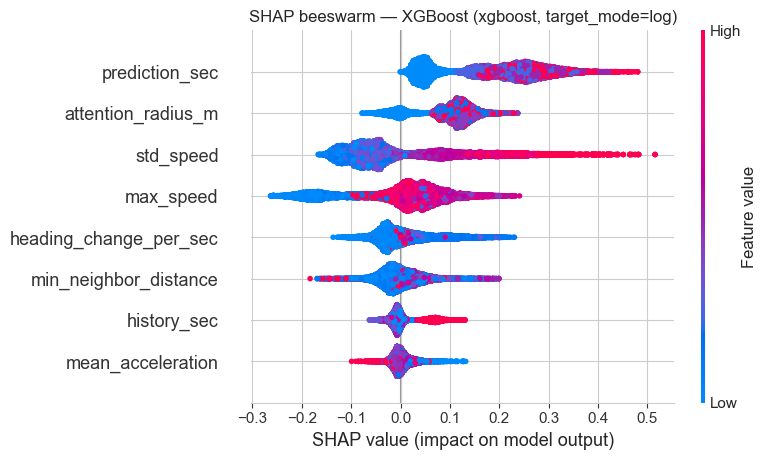

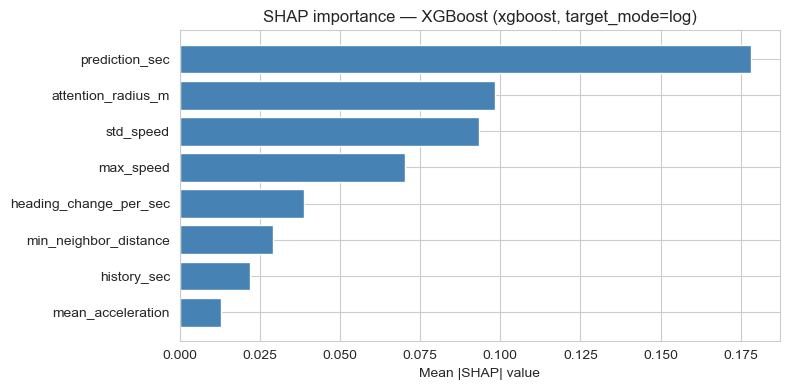

Feature-effect ranking table saved to: <repo>/results/interpretable_model/xgboost/sweep_large_30ep_1seed_MI_corrected/tables/feature_effect_importance_ml_ade_log.csv
Feature-effect table saved to:         <repo>/results/interpretable_model/xgboost/sweep_large_30ep_1seed_MI_corrected/tables/feature_effects_ml_ade_log.csv
SHAP beeswarm saved to:               <repo>/results/interpretable_model/xgboost/sweep_large_30ep_1seed_MI_corrected/plots/shap_beeswarm_ml_ade_log.png
Feature-effect importance plot saved to: <repo>/results/interpretable_model/xgboost/sweep_large_30ep_1seed_MI_corrected/plots/feature_effect_importance_ml_ade_log.png
Features selected for downstream effect plots (up to 16, ranked):
['prediction_sec', 'attention_radius_m', 'std_speed', 'max_speed', 'heading_change_per_sec', 'min_neighbor_distance', 'history_sec', 'mean_acceleration']


In [51]:
# Use a model-specific explanation method while keeping the exported feature-effect
# table/ranking schema common across XGBoost and GAM runs.
feature_effect_table_path = TABLES_DIR / f"feature_effects_{target_col}.csv"
importance_table_path = TABLES_DIR / f"feature_effect_importance_{target_col}.csv"
importance_plot_path = PLOTS_DIR / f"feature_effect_importance_{target_col}.png"

if MODEL_ID == "xgboost":
    try:
        explainer = shap.Explainer(model, X_for_model)
        shap_exp = explainer(X_for_model)
    except NotImplementedError as exc:
        if "Categorical split is not yet supported" in str(exc):
            print(
                "SHAP fallback: using TreeExplainer with "
                "feature_perturbation='tree_path_dependent' for categorical splits."
            )
            explainer = shap.TreeExplainer(
                model, feature_perturbation="tree_path_dependent"
            )
            shap_exp = explainer(X_for_model)
        else:
            raise

    feature_effect_values = shap_exp.values

    importance_df = build_feature_effect_importance_table(
        model_id=MODEL_ID,
        feature_cols=feature_cols,
        effect_values=feature_effect_values,
    )
    display(importance_df)
    importance_df.to_csv(importance_table_path, index=False)

    feature_effect_df = prepare_feature_effect_export(
        model_df_oof=model_df_oof,
        feature_cols=feature_cols,
        effect_values=feature_effect_values,
        base_values=getattr(shap_exp, "base_values", None),
    )
    feature_effect_df.to_csv(feature_effect_table_path, index=False)

    ranked_features = importance_df["feature"].tolist()
    effect_features = ranked_features[:16]

    plt.figure(figsize=(10, 6))
    shap.summary_plot(feature_effect_values, X_for_model, show=False, max_display=20)
    plt.title(f"SHAP beeswarm — {exported_model_label}")
    beeswarm_path = PLOTS_DIR / f"shap_beeswarm_{target_col}.png"
    plt.tight_layout()
    plt.savefig(beeswarm_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

    fig, ax = plt.subplots(figsize=(8, max(4, len(feature_cols) * 0.4)))
    plot_df = importance_df.sort_values("mean_abs_shap", ascending=True)
    ax.barh(plot_df["feature"], plot_df["mean_abs_shap"], color="steelblue")
    ax.set_xlabel("Mean |SHAP| value")
    ax.set_title(f"SHAP importance — {exported_model_label}")
    plt.tight_layout()
    plt.savefig(importance_plot_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    print(f"Feature-effect ranking table saved to: {importance_table_path}")
    print(f"Feature-effect table saved to:         {feature_effect_table_path}")
    print(f"SHAP beeswarm saved to:               {beeswarm_path}")
    print(f"Feature-effect importance plot saved to: {importance_plot_path}")
elif MODEL_ID == "gam":
    p_values = np.asarray(
        model.statistics_["p_values"][: len(feature_cols)], dtype=float
    )
    feature_effect_values, effect_base_values = compute_gam_feature_effects(
        model=model,
        X_scaled=X_for_model,
        feature_cols=feature_cols,
    )

    feature_effect_df = prepare_feature_effect_export(
        model_df_oof=model_df_oof,
        feature_cols=feature_cols,
        effect_values=feature_effect_values,
        base_values=effect_base_values,
    )
    feature_effect_df.to_csv(feature_effect_table_path, index=False)

    importance_df = build_feature_effect_importance_table(
        model_id=MODEL_ID,
        feature_cols=feature_cols,
        p_values=p_values,
    )
    display(importance_df)
    importance_df.to_csv(importance_table_path, index=False)

    ranked_features = importance_df["feature"].tolist()
    effect_features = ranked_features[:16]

    fig, ax = plt.subplots(figsize=(8, max(4, len(feature_cols) * 0.4)))
    plot_df = importance_df.sort_values("neg_log10_p_value", ascending=True)
    ax.barh(plot_df["feature"], plot_df["neg_log10_p_value"], color="steelblue")
    ax.axvline(
        x=-np.log10(0.05), color="red", linestyle="--", label="p=0.05", alpha=0.7
    )
    ax.axvline(
        x=-np.log10(0.01), color="orange", linestyle="--", label="p=0.01", alpha=0.7
    )
    ax.set_xlabel("-log10(p-value)")
    ax.set_title(f"Smooth effect significance — {exported_model_label}")
    ax.legend()
    plt.tight_layout()
    plt.savefig(importance_plot_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    beeswarm_path = None
    print(f"Feature-effect ranking table saved to: {importance_table_path}")
    print(f"Feature-effect table saved to:         {feature_effect_table_path}")
    print(f"Feature-effect importance plot saved to: {importance_plot_path}")
else:
    raise NotImplementedError(
        f"Model inference analysis is not implemented yet for model_id={MODEL_ID}"
    )

print("Features selected for downstream effect plots (up to 16, ranked):")
print(effect_features)

## 4. Feature Effect Plots
**Purpose:** Visualize how the fitted model responds to changes in individual features.<br>
**Inputs:** loaded model, modelling feature matrix, and the selected effect-feature subset.<br>
**Outputs:** a grid of model-specific feature-effect plots saved to disk, plus pairwise 2D PDP interaction plots for XGBoost runs.<br>
**How to Verify:** confirm the grids render without missing-feature errors and that each plotted feature exists in `feature_cols`.


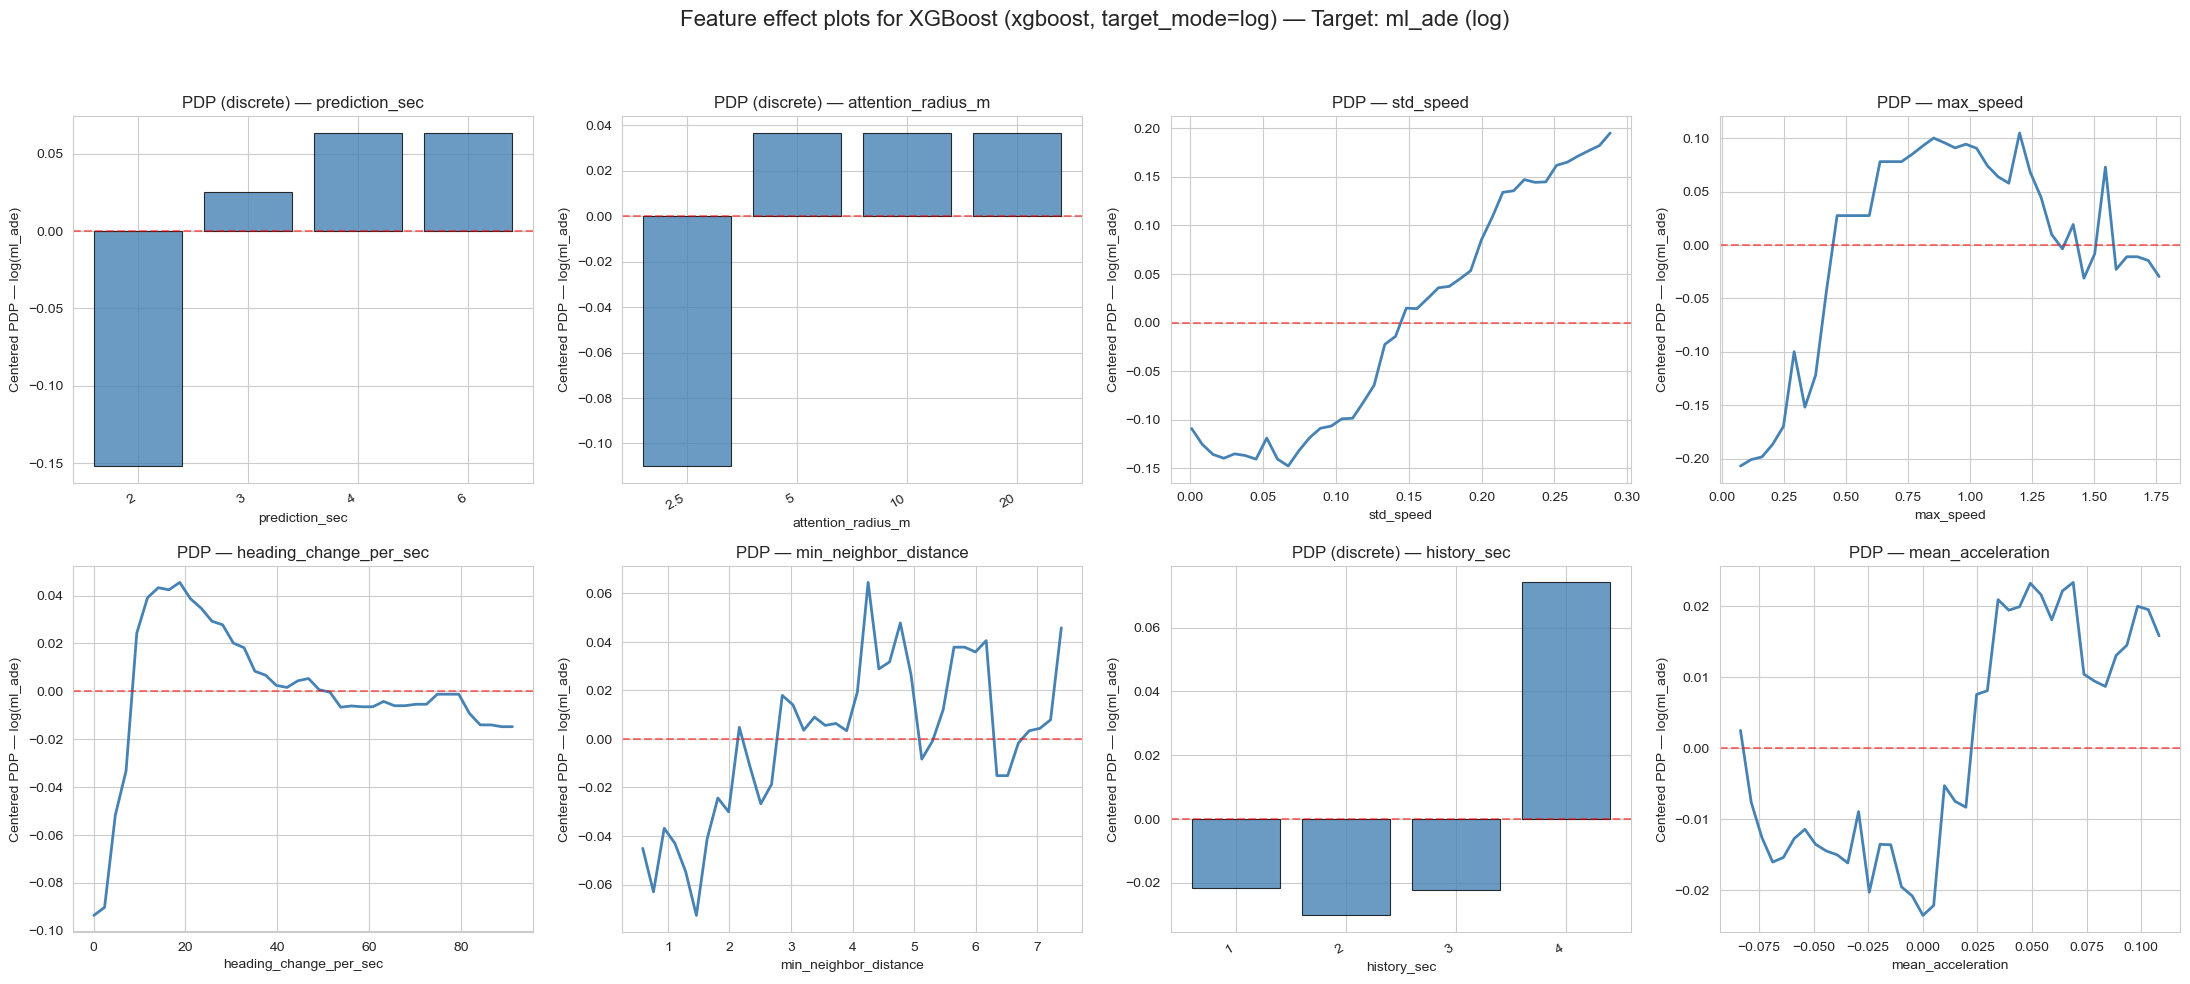

Feature effect grid saved for the ranked feature set.
Feature effect grid path: <repo>/results/interpretable_model/xgboost/sweep_large_30ep_1seed_MI_corrected/plots/feature_effects_grid_ml_ade_log.png


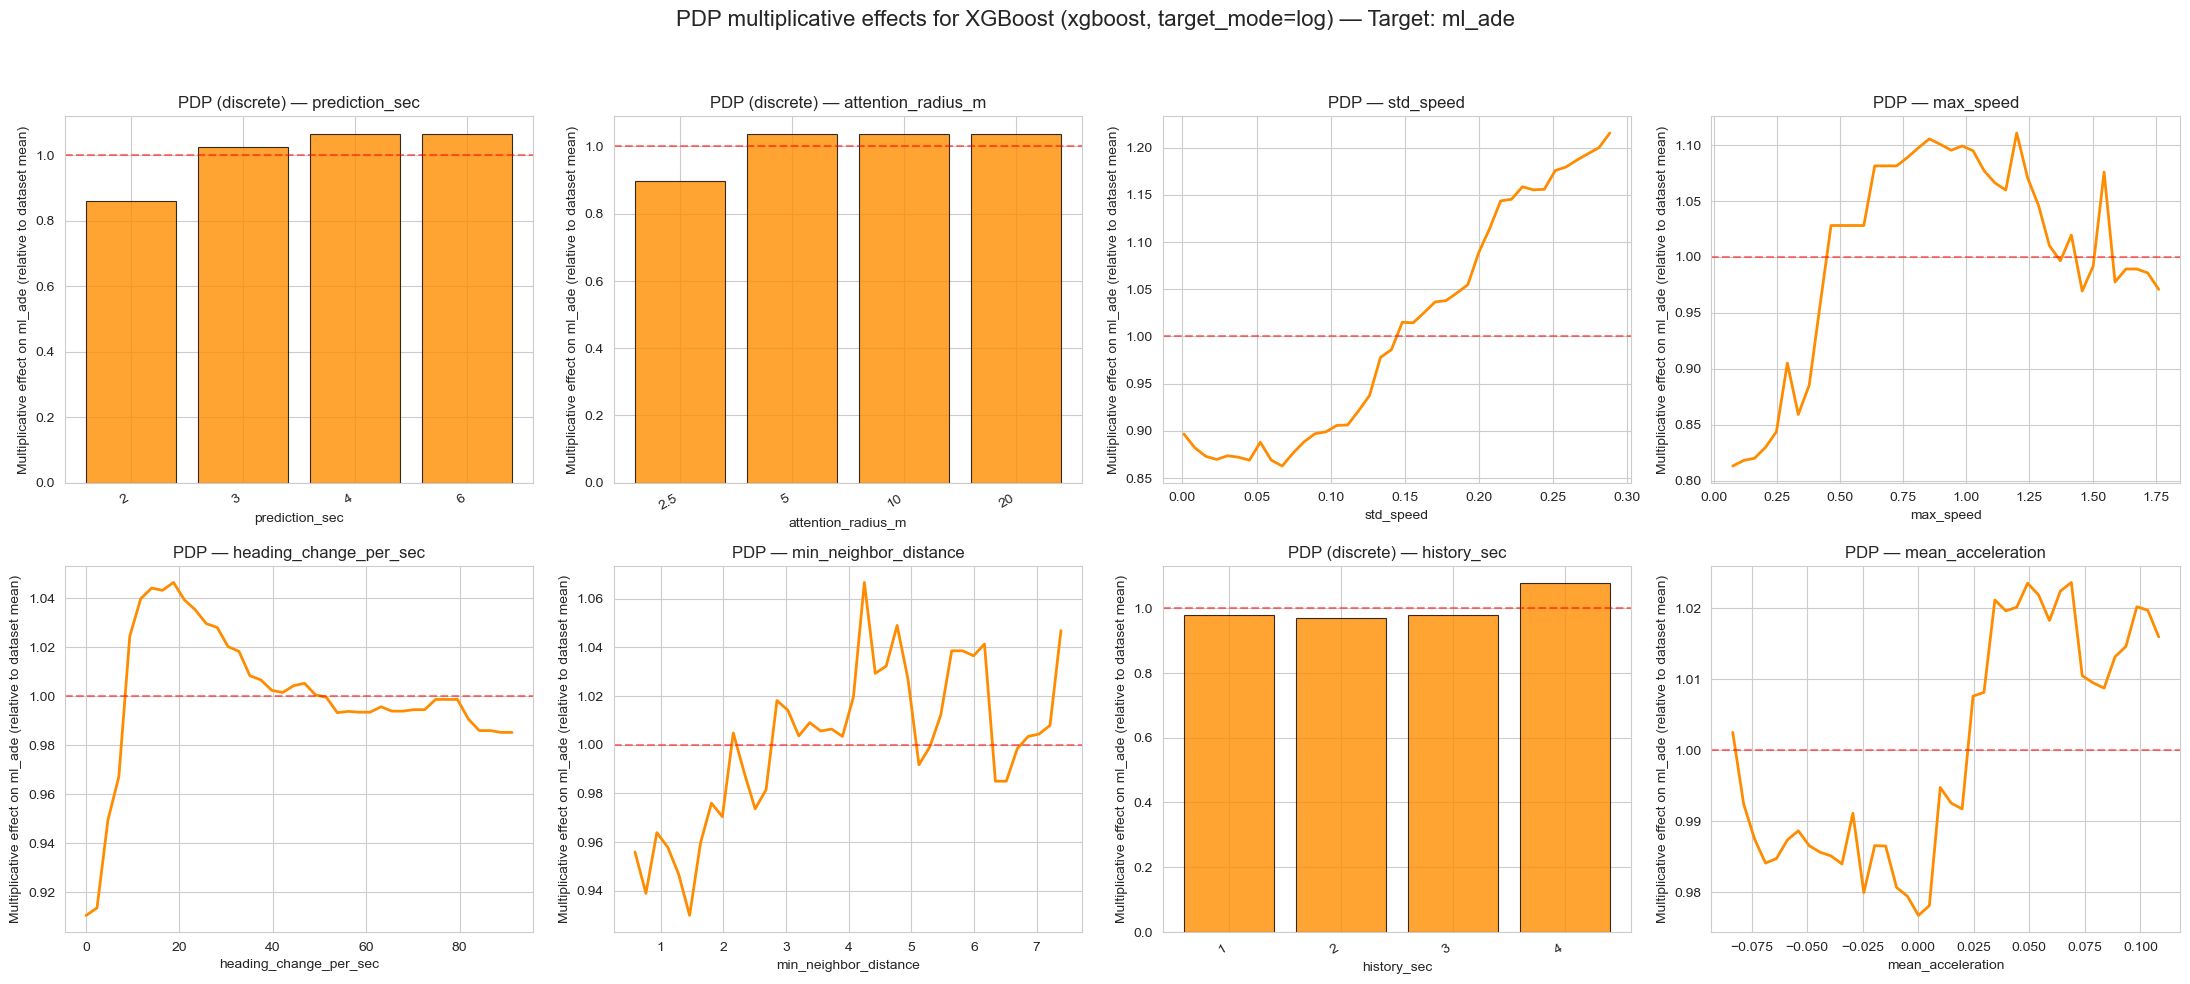

Feature effect multiplicative grid path: <repo>/results/interpretable_model/xgboost/sweep_large_30ep_1seed_MI_corrected/plots/feature_effects_grid_mult_ml_ade_log.png


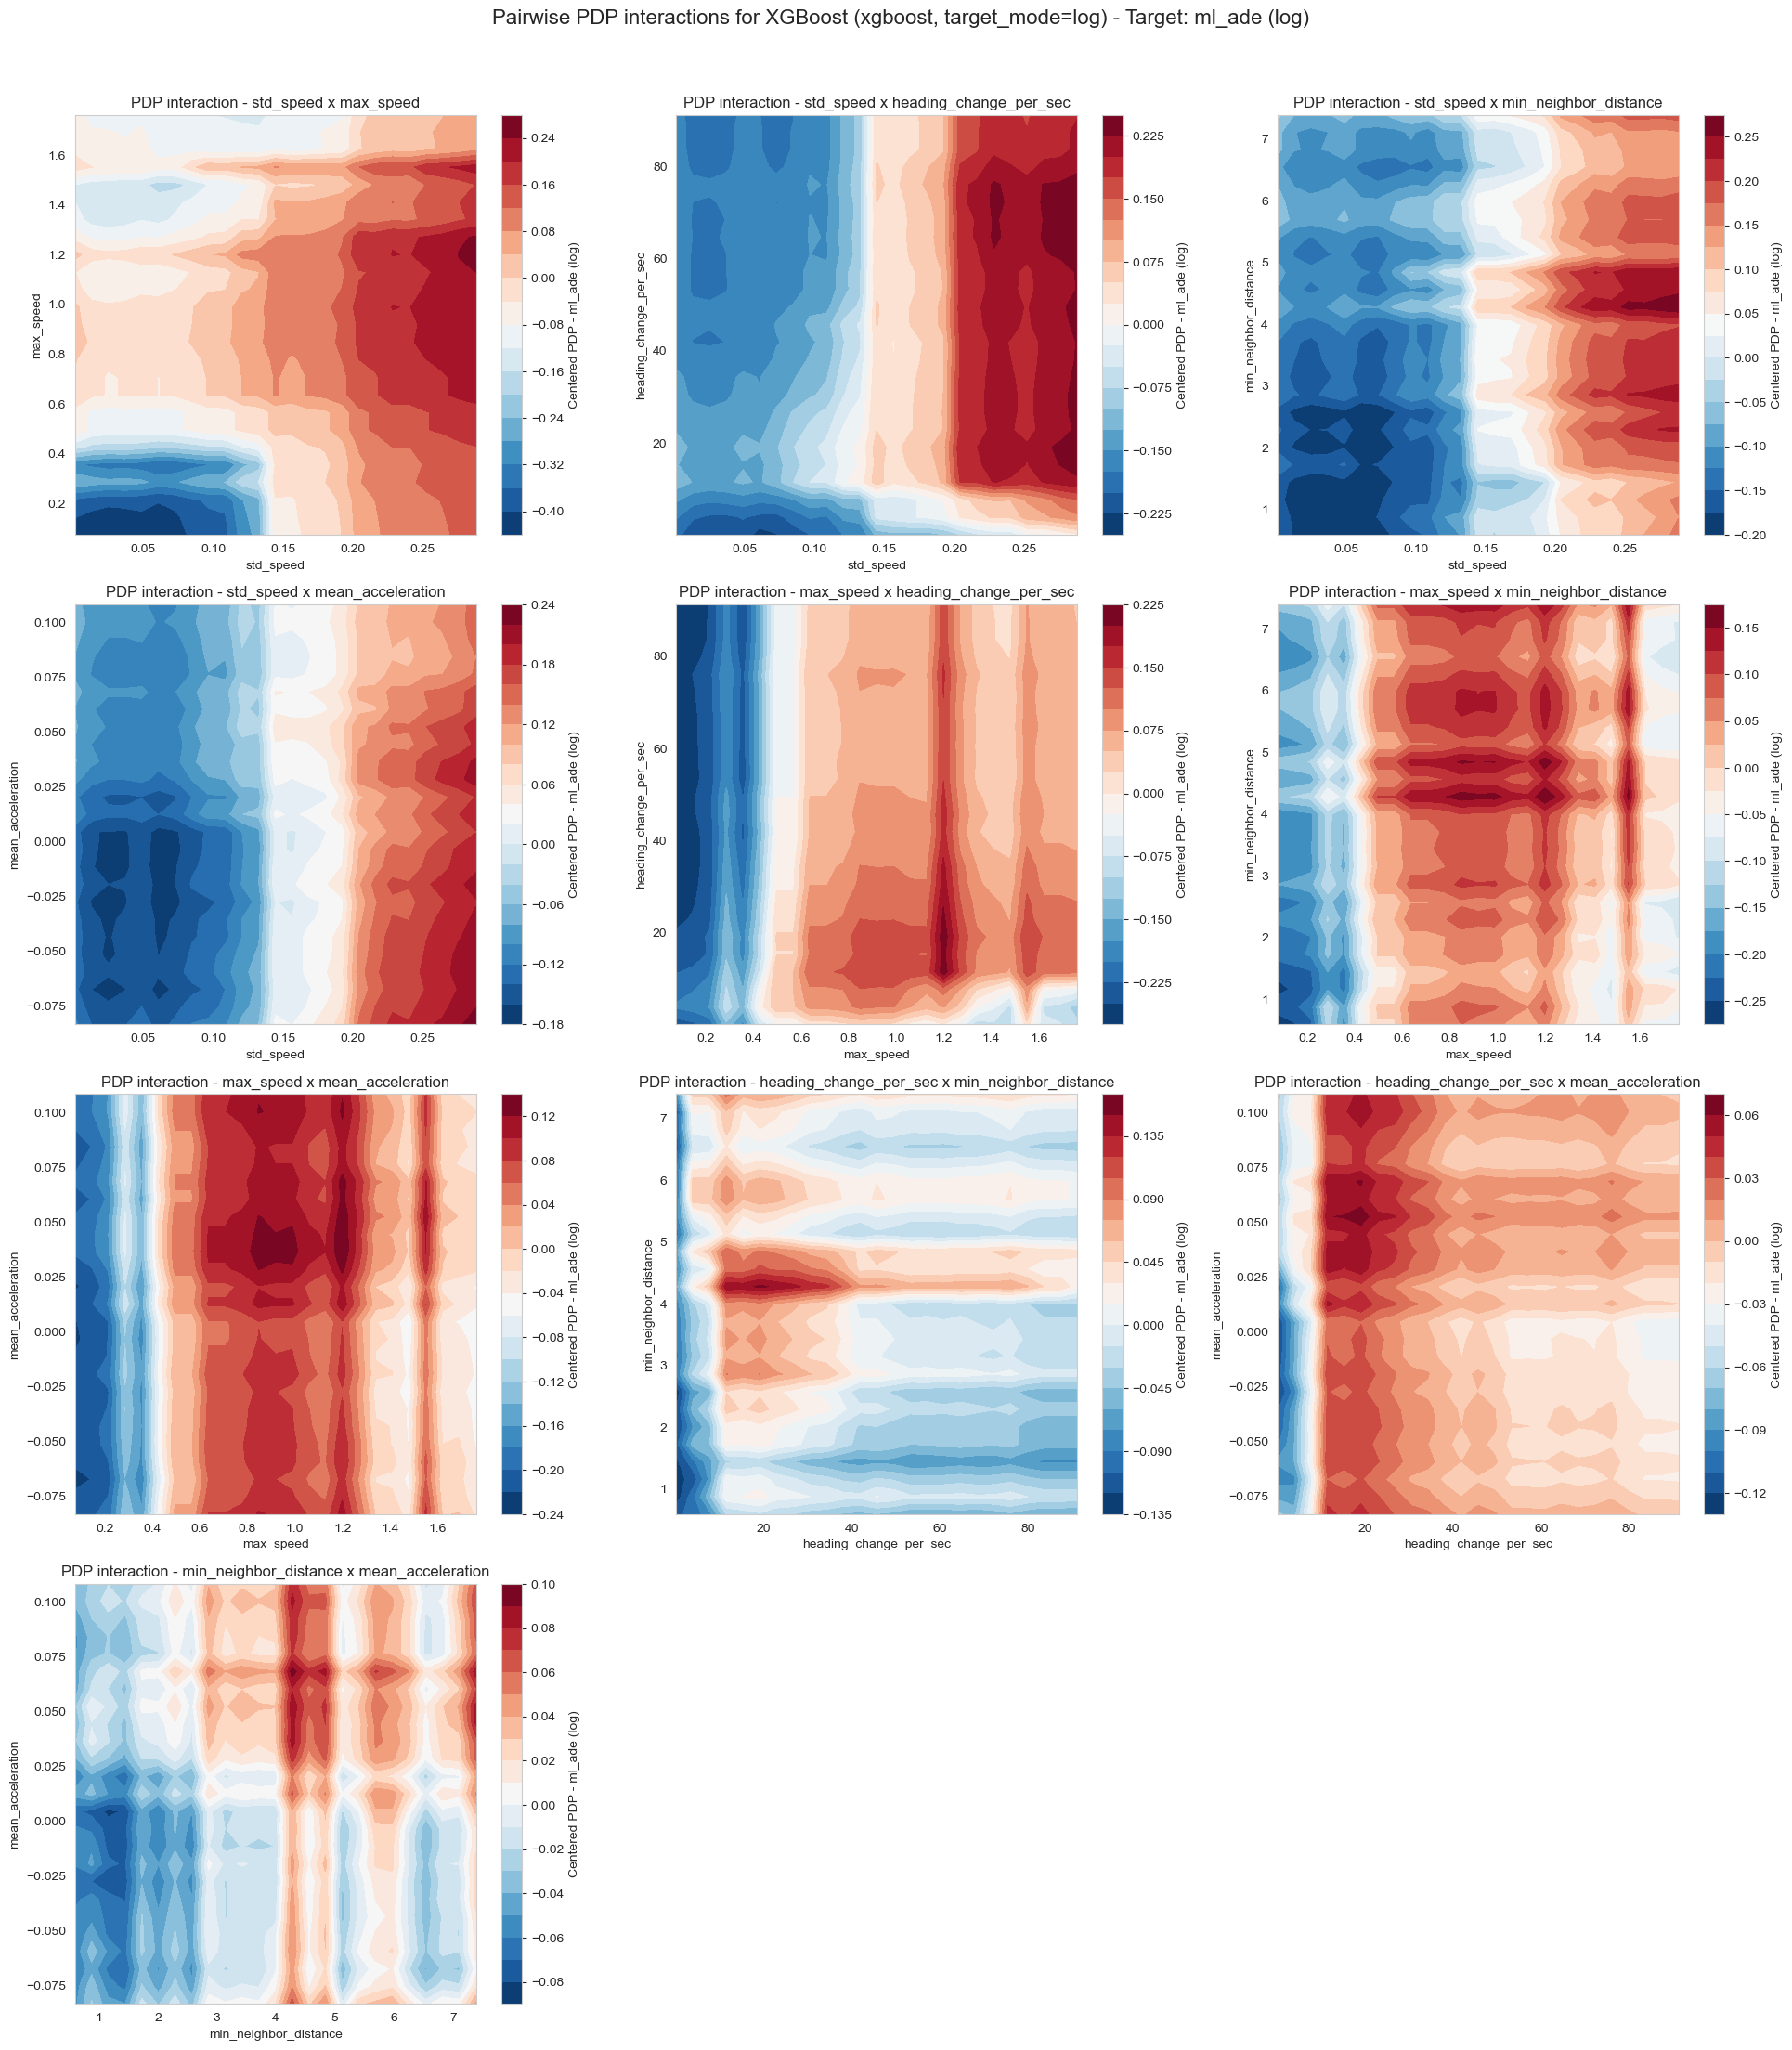

Pairwise PDP interaction grid saved for the top non-discrete ranked features.
PDP interaction grid path: <repo>/results/interpretable_model/xgboost/sweep_large_30ep_1seed_MI_corrected/plots/pdp_interactions_ml_ade_log.png


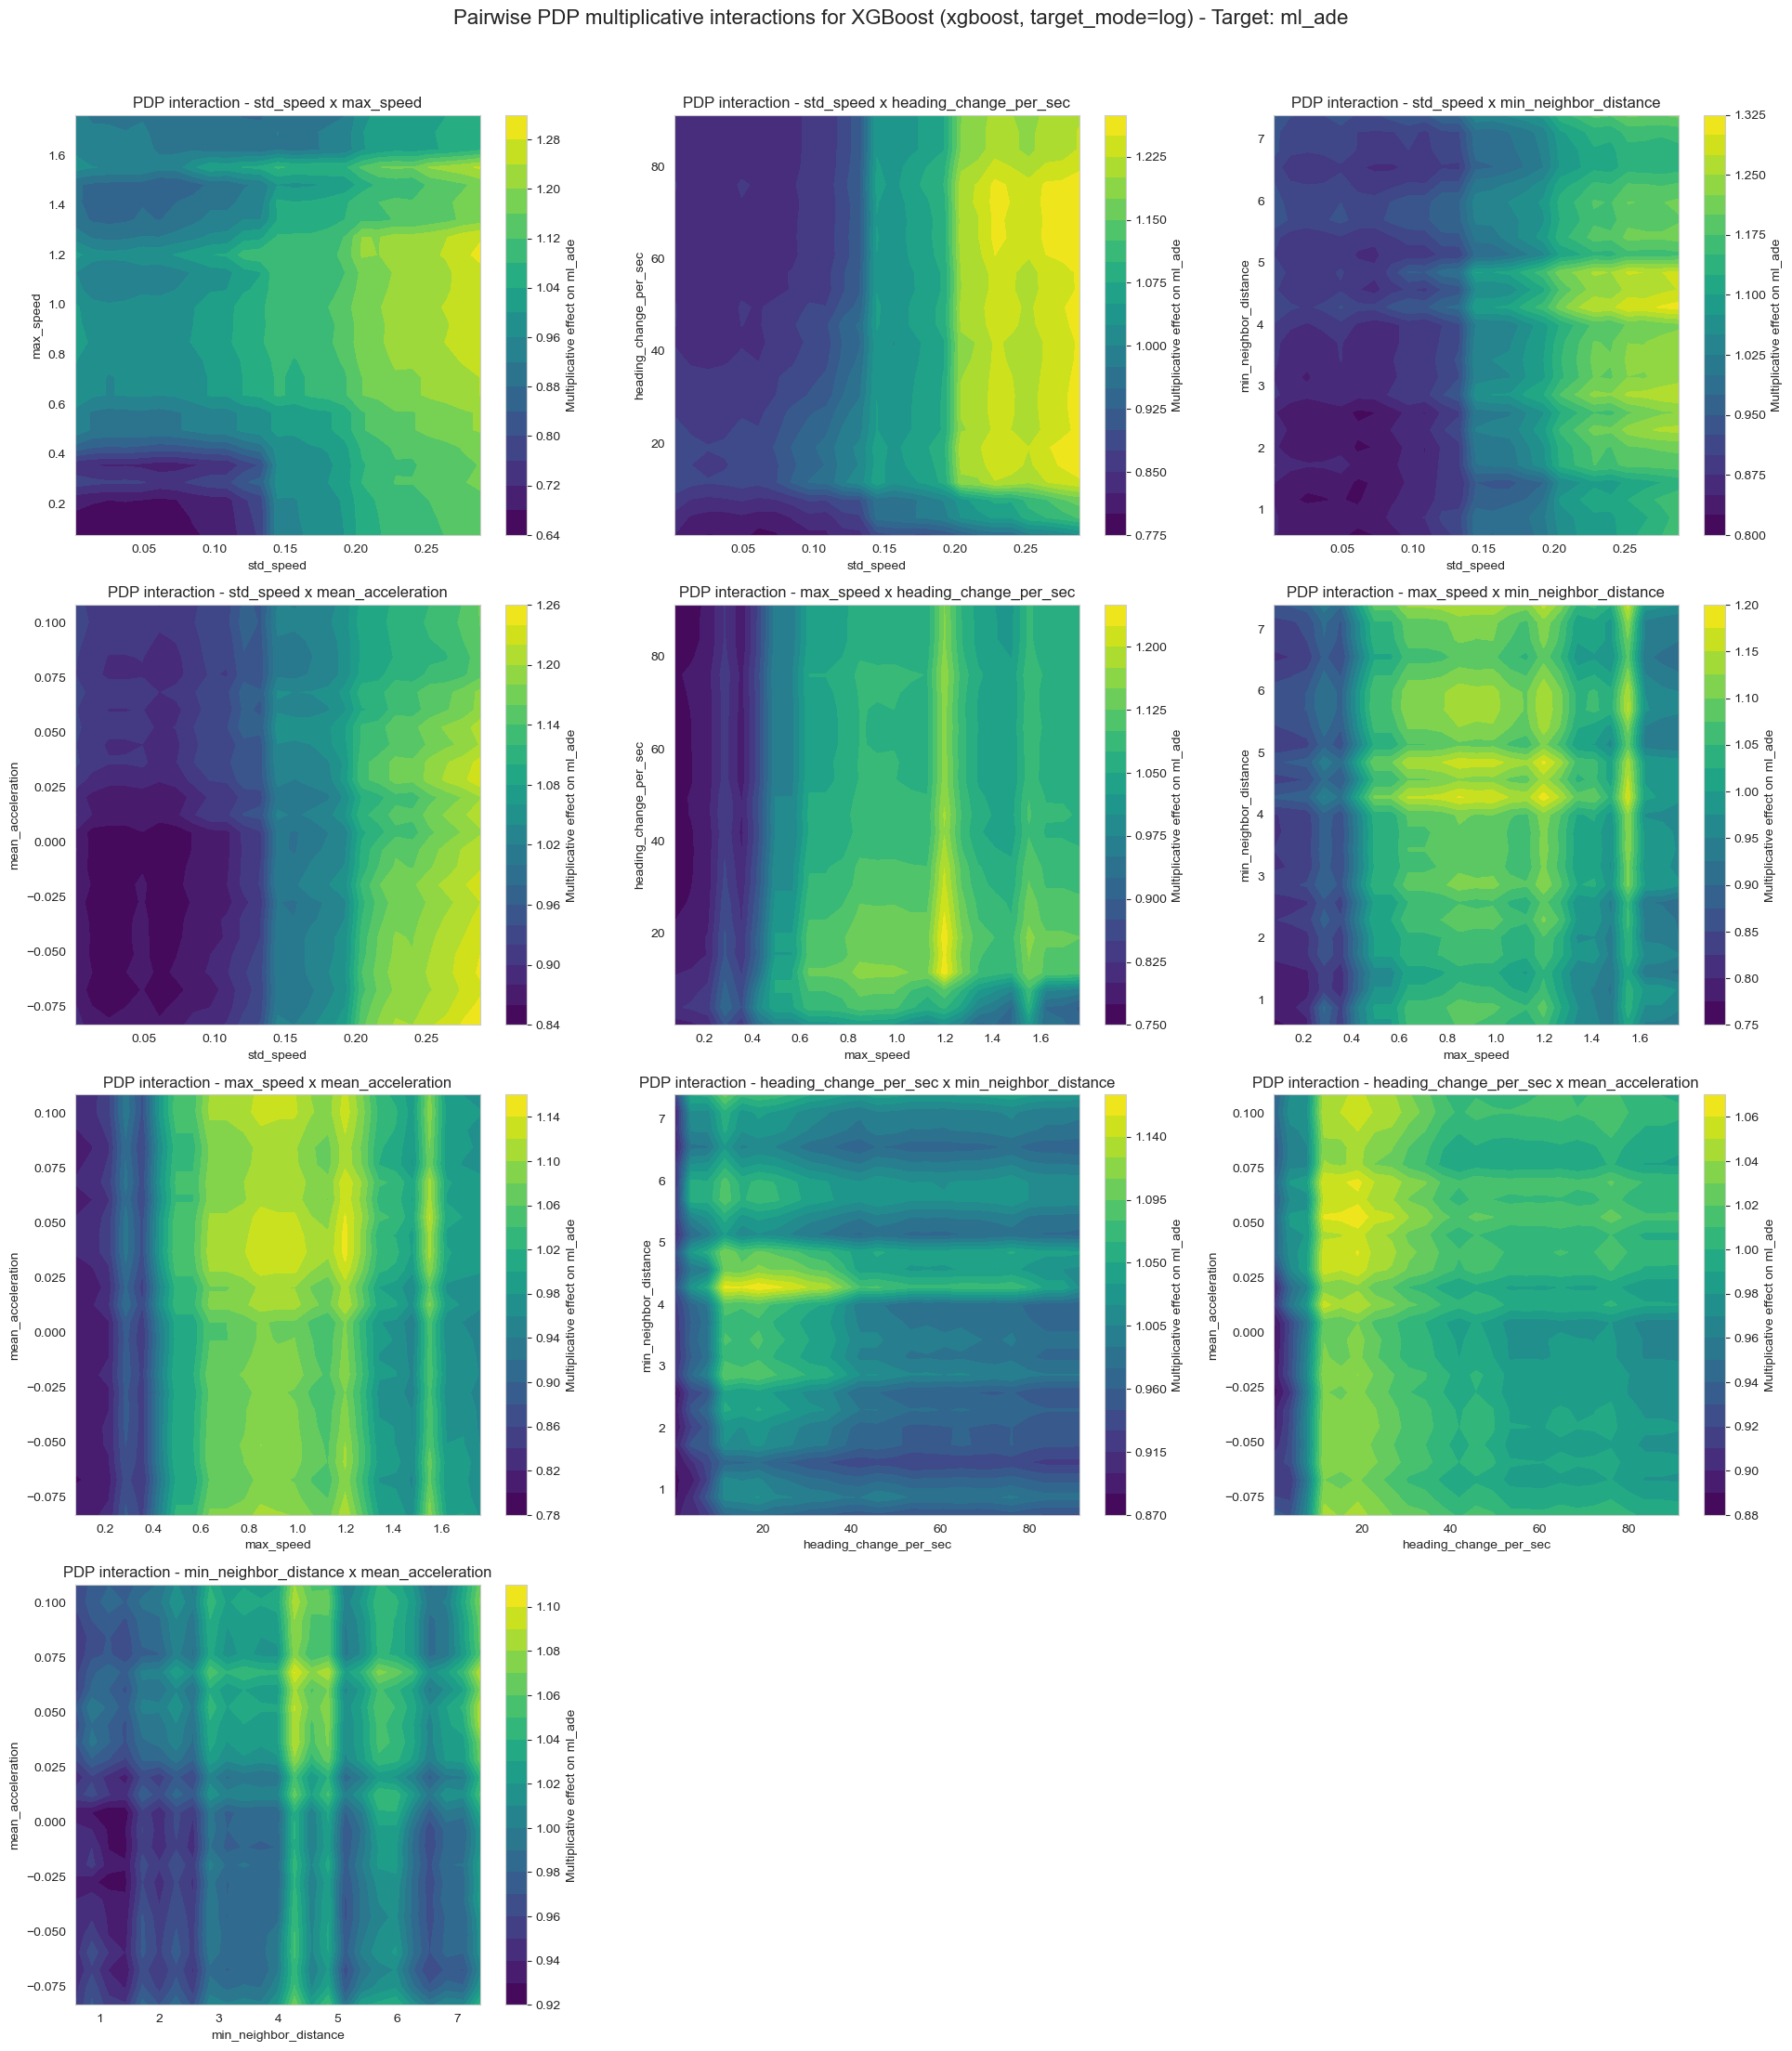

PDP interaction multiplicative grid path: <repo>/results/interpretable_model/xgboost/sweep_large_30ep_1seed_MI_corrected/plots/pdp_interactions_mult_ml_ade_log.png


In [52]:
# Plot feature effects using the fitted final model rather than OOF predictions so the
# shapes reflect the exact exported artifact that downstream users will inspect.
# Discrete model settings (attention_radius_m, history_sec, prediction_sec) are rendered
# as bar charts at their actual levels; continuous features keep the smooth line/PDP.
fig, axes = plt.subplots(4, 4, figsize=(22, 18))
axes = axes.flatten()

display_target_col = resolve_raw_metric_col(manifest, target_col)
target_mode_label = "log" if selected_target_mode == "log" else "raw"
target_label = f"{display_target_col} ({target_mode_label})"

if MODEL_ID == "xgboost":
    # Pre-compute raw PDP values once; reused for both the centered additive and
    # multiplicative plots below.
    _pdp_cache = {}
    for feat in effect_features:
        if feat in discrete_feature_names:
            unique_vals = sorted(X[feat].unique())
            raw_means = []
            for v in unique_vals:
                X_copy = X_for_model.copy()
                X_copy[feat] = v
                raw_means.append(float(model.predict(X_copy).mean()))
            y = np.array(raw_means)
            _pdp_cache[feat] = {
                "type": "discrete",
                "x": unique_vals,
                "y_centered": y - y.mean(),
            }
        else:
            res = partial_dependence(
                model, X_for_model, features=[feat], kind="average", grid_resolution=40
            )
            y = res["average"][0]
            _pdp_cache[feat] = {
                "type": "continuous",
                "x": res["grid_values"][0],
                "y_centered": y - y.mean(),
            }

    for ax, feat in zip(axes, effect_features):
        d = _pdp_cache[feat]
        y_c = d["y_centered"]
        if d["type"] == "discrete":
            x_pos = range(len(d["x"]))
            ax.bar(
                x_pos,
                y_c,
                color="steelblue",
                alpha=0.8,
                edgecolor="black",
                linewidth=0.8,
            )
            ax.axhline(0, color="red", linestyle="--", alpha=0.5)
            ax.set_xticks(list(x_pos))
            ax.set_xticklabels([f"{v:.4g}" for v in d["x"]], rotation=30, ha="right")
            ax.set_title(f"PDP (discrete) — {feat}")
        else:
            ax.plot(d["x"], y_c, color="steelblue", linewidth=2)
            ax.axhline(0, color="red", linestyle="--", alpha=0.5)
            ax.set_title(f"PDP — {feat}")
        ax.set_xlabel(feat)
        ax.set_ylabel(f"Centered PDP — log({display_target_col})")

elif MODEL_ID == "gam":
    ylabel = (
        f"Additive effect on {display_target_col} (log scale)"
        if selected_target_mode == "log"
        else f"Additive effect on {display_target_col}"
    )
    for ax, feat in zip(axes, effect_features):
        feat_idx = feature_cols.index(feat)
        if feat in discrete_feature_names:
            # Factor term: evaluate at the actual discrete levels observed in the data
            unique_raw_vals = np.array(sorted(X[feat].unique()))
            x_scaled = (unique_raw_vals - scaler.mean_[feat_idx]) / scaler.scale_[
                feat_idx
            ]
            XX = np.tile(X_for_model.mean(axis=0), (len(x_scaled), 1))
            XX[:, feat_idx] = x_scaled
            pdep, confi = model.partial_dependence(term=feat_idx, X=XX, width=0.95)
            x_pos = np.arange(len(unique_raw_vals))
            ax.bar(
                x_pos,
                pdep,
                color="steelblue",
                alpha=0.8,
                edgecolor="black",
                linewidth=0.8,
            )
            ax.errorbar(
                x_pos,
                pdep,
                yerr=[pdep - confi[:, 0], confi[:, 1] - pdep],
                fmt="none",
                color="black",
                capsize=4,
                linewidth=1.2,
            )
            ax.axhline(0, color="red", linestyle="--", alpha=0.5)
            ax.set_xticks(x_pos)
            ax.set_xticklabels(
                [f"{v:.4g}" for v in unique_raw_vals], rotation=30, ha="right"
            )
            ax.set_title(f"Factor effect — {feat}")
        else:
            XX = model.generate_X_grid(term=feat_idx)
            pdep, confi = model.partial_dependence(term=feat_idx, X=XX, width=0.95)
            x_scaled_cont = XX[:, feat_idx]
            x_original = (
                x_scaled_cont * scaler.scale_[feat_idx] + scaler.mean_[feat_idx]
            )
            ax.plot(x_original, pdep, color="steelblue", linewidth=2)
            ax.fill_between(
                x_original, confi[:, 0], confi[:, 1], alpha=0.2, color="steelblue"
            )
            ax.axhline(0, color="red", linestyle="--", alpha=0.5)
            ax.set_title(f"Smooth additive effect — {feat}")
        ax.set_xlabel(feat)
        ax.set_ylabel(ylabel)
else:
    raise NotImplementedError(
        f"Model inference analysis is not implemented yet for model_id={MODEL_ID}"
    )

for ax in axes[len(effect_features) :]:
    ax.set_visible(False)

plt.suptitle(
    f"Feature effect plots for {exported_model_label} — Target: {target_label}",
    fontsize=16,
    y=1.02,
)
plt.tight_layout()
effect_plot_path = PLOTS_DIR / f"feature_effects_grid_{target_col}.png"
plt.savefig(effect_plot_path, dpi=150, bbox_inches="tight")
plt.show()

print("Feature effect grid saved for the ranked feature set.")
print(f"Feature effect grid path: {effect_plot_path}")
if MODEL_ID == "gam" and selected_target_mode == "log":
    print(
        "GAM note: additive effects are exported and plotted on the log/link scale; they imply multiplicative changes on the original target scale."
    )

# Multiplicative-scale PDP: exp(centered PDP) gives a factor relative to the geometric
# mean prediction, i.e. how much higher/lower ml_ade is at each feature value compared
# to the dataset average. Only meaningful when the model fits a log-transformed target.
effect_plot_mult_path = None
if MODEL_ID == "xgboost" and target_col.endswith("_log"):
    fig_mult, axes_mult = plt.subplots(4, 4, figsize=(22, 18))
    axes_mult = axes_mult.flatten()

    for ax, feat in zip(axes_mult, effect_features):
        d = _pdp_cache[feat]
        y_mult = np.exp(d["y_centered"])
        if d["type"] == "discrete":
            x_pos = range(len(d["x"]))
            ax.bar(
                x_pos,
                y_mult,
                color="darkorange",
                alpha=0.8,
                edgecolor="black",
                linewidth=0.8,
            )
            ax.axhline(1.0, color="red", linestyle="--", alpha=0.5)
            ax.set_xticks(list(x_pos))
            ax.set_xticklabels([f"{v:.4g}" for v in d["x"]], rotation=30, ha="right")
            ax.set_title(f"PDP (discrete) — {feat}")
        else:
            ax.plot(d["x"], y_mult, color="darkorange", linewidth=2)
            ax.axhline(1.0, color="red", linestyle="--", alpha=0.5)
            ax.set_title(f"PDP — {feat}")
        ax.set_xlabel(feat)
        ax.set_ylabel(
            f"Multiplicative effect on {display_target_col} (relative to dataset mean)"
        )

    for ax in axes_mult[len(effect_features) :]:
        ax.set_visible(False)

    plt.suptitle(
        f"PDP multiplicative effects for {exported_model_label} — Target: {display_target_col}",
        fontsize=16,
        y=1.02,
    )
    plt.tight_layout()
    effect_plot_mult_path = PLOTS_DIR / f"feature_effects_grid_mult_{target_col}.png"
    plt.savefig(effect_plot_mult_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Feature effect multiplicative grid path: {effect_plot_mult_path}")

# Pairwise PDP interaction surfaces are only generated for the XGBoost PDP workflow.
# The GAM branch above visualizes additive terms; without fitted interaction terms there is
# no comparable 2D surface to plot.
interaction_plot_path = None
interaction_plot_mult_path = None
if MODEL_ID == "xgboost":
    interaction_features = [
        feat for feat in effect_features if feat not in discrete_feature_names
    ][:PDP_INTERACTION_TOP_FEATURES]
    interaction_feature_pairs = [
        (feat_a, feat_b)
        for idx, feat_a in enumerate(interaction_features)
        for feat_b in interaction_features[idx + 1 :]
    ]

    if interaction_feature_pairs:
        n_pairs = len(interaction_feature_pairs)
        n_cols = min(3, n_pairs)
        n_rows = int(np.ceil(n_pairs / n_cols))
        fig_int, axes_int = plt.subplots(
            n_rows,
            n_cols,
            figsize=(6.5 * n_cols, 5.4 * n_rows),
            squeeze=False,
        )
        axes_int = axes_int.flatten()
        interaction_pdp_cache = {}

        for ax, (feat_a, feat_b) in zip(axes_int, interaction_feature_pairs):
            feat_a_idx = feature_cols.index(feat_a)
            feat_b_idx = feature_cols.index(feat_b)
            res = partial_dependence(
                model,
                X_for_model,
                features=[(feat_a_idx, feat_b_idx)],
                kind="average",
                grid_resolution=PDP_INTERACTION_GRID_RESOLUTION,
            )
            grid_a, grid_b = res["grid_values"]
            pdp = res["average"][0]
            pdp_centered = pdp - pdp.mean()
            interaction_pdp_cache[(feat_a, feat_b)] = {
                "grid_a": grid_a,
                "grid_b": grid_b,
                "pdp_centered": pdp_centered,
            }
            xx, yy = np.meshgrid(grid_a, grid_b)
            contour = ax.contourf(
                xx,
                yy,
                pdp_centered.T,
                levels=20,
                cmap="RdBu_r",
            )
            fig_int.colorbar(contour, ax=ax, label=f"Centered PDP - {target_label}")
            ax.set_xlabel(feat_a)
            ax.set_ylabel(feat_b)
            ax.set_title(f"PDP interaction - {feat_a} x {feat_b}")

        for ax in axes_int[n_pairs:]:
            ax.set_visible(False)

        plt.suptitle(
            f"Pairwise PDP interactions for {exported_model_label} - Target: {target_label}",
            fontsize=16,
            y=1.02,
        )
        plt.tight_layout()
        interaction_plot_path = PLOTS_DIR / f"pdp_interactions_{target_col}.png"
        plt.savefig(interaction_plot_path, dpi=150, bbox_inches="tight")
        plt.show()
        print("Pairwise PDP interaction grid saved for the top non-discrete ranked features.")
        print(f"PDP interaction grid path: {interaction_plot_path}")

        if target_col.endswith("_log"):
            fig_int_mult, axes_int_mult = plt.subplots(
                n_rows,
                n_cols,
                figsize=(6.5 * n_cols, 5.4 * n_rows),
                squeeze=False,
            )
            axes_int_mult = axes_int_mult.flatten()

            for ax, (feat_a, feat_b) in zip(axes_int_mult, interaction_feature_pairs):
                d = interaction_pdp_cache[(feat_a, feat_b)]
                xx, yy = np.meshgrid(d["grid_a"], d["grid_b"])
                contour = ax.contourf(
                    xx,
                    yy,
                    np.exp(d["pdp_centered"]).T,
                    levels=20,
                    cmap="viridis",
                )
                fig_int_mult.colorbar(
                    contour,
                    ax=ax,
                    label=f"Multiplicative effect on {display_target_col}",
                )
                ax.set_xlabel(feat_a)
                ax.set_ylabel(feat_b)
                ax.set_title(f"PDP interaction - {feat_a} x {feat_b}")

            for ax in axes_int_mult[n_pairs:]:
                ax.set_visible(False)

            plt.suptitle(
                f"Pairwise PDP multiplicative interactions for {exported_model_label} - Target: {display_target_col}",
                fontsize=16,
                y=1.02,
            )
            plt.tight_layout()
            interaction_plot_mult_path = (
                PLOTS_DIR / f"pdp_interactions_mult_{target_col}.png"
            )
            plt.savefig(interaction_plot_mult_path, dpi=150, bbox_inches="tight")
            plt.show()
            print(f"PDP interaction multiplicative grid path: {interaction_plot_mult_path}")
    else:
        print(
            "Skipping pairwise PDP interactions: fewer than two non-discrete ranked features are available."
        )

## 5. Cohort Violin Plots by Actual Performance
**Purpose:** Compare feature distributions between high-performing and low-performing trajectories using the actual target on the original scale.<br>
**Inputs:** `target_orig`, configured quantile threshold, and selected cohort features.<br>
**Outputs:** quantile-defined cohort masks and a saved violin-plot figure.<br>
**How to Verify:** confirm the printed thresholds are sensible for the target distribution and that both cohorts contain non-zero rows.


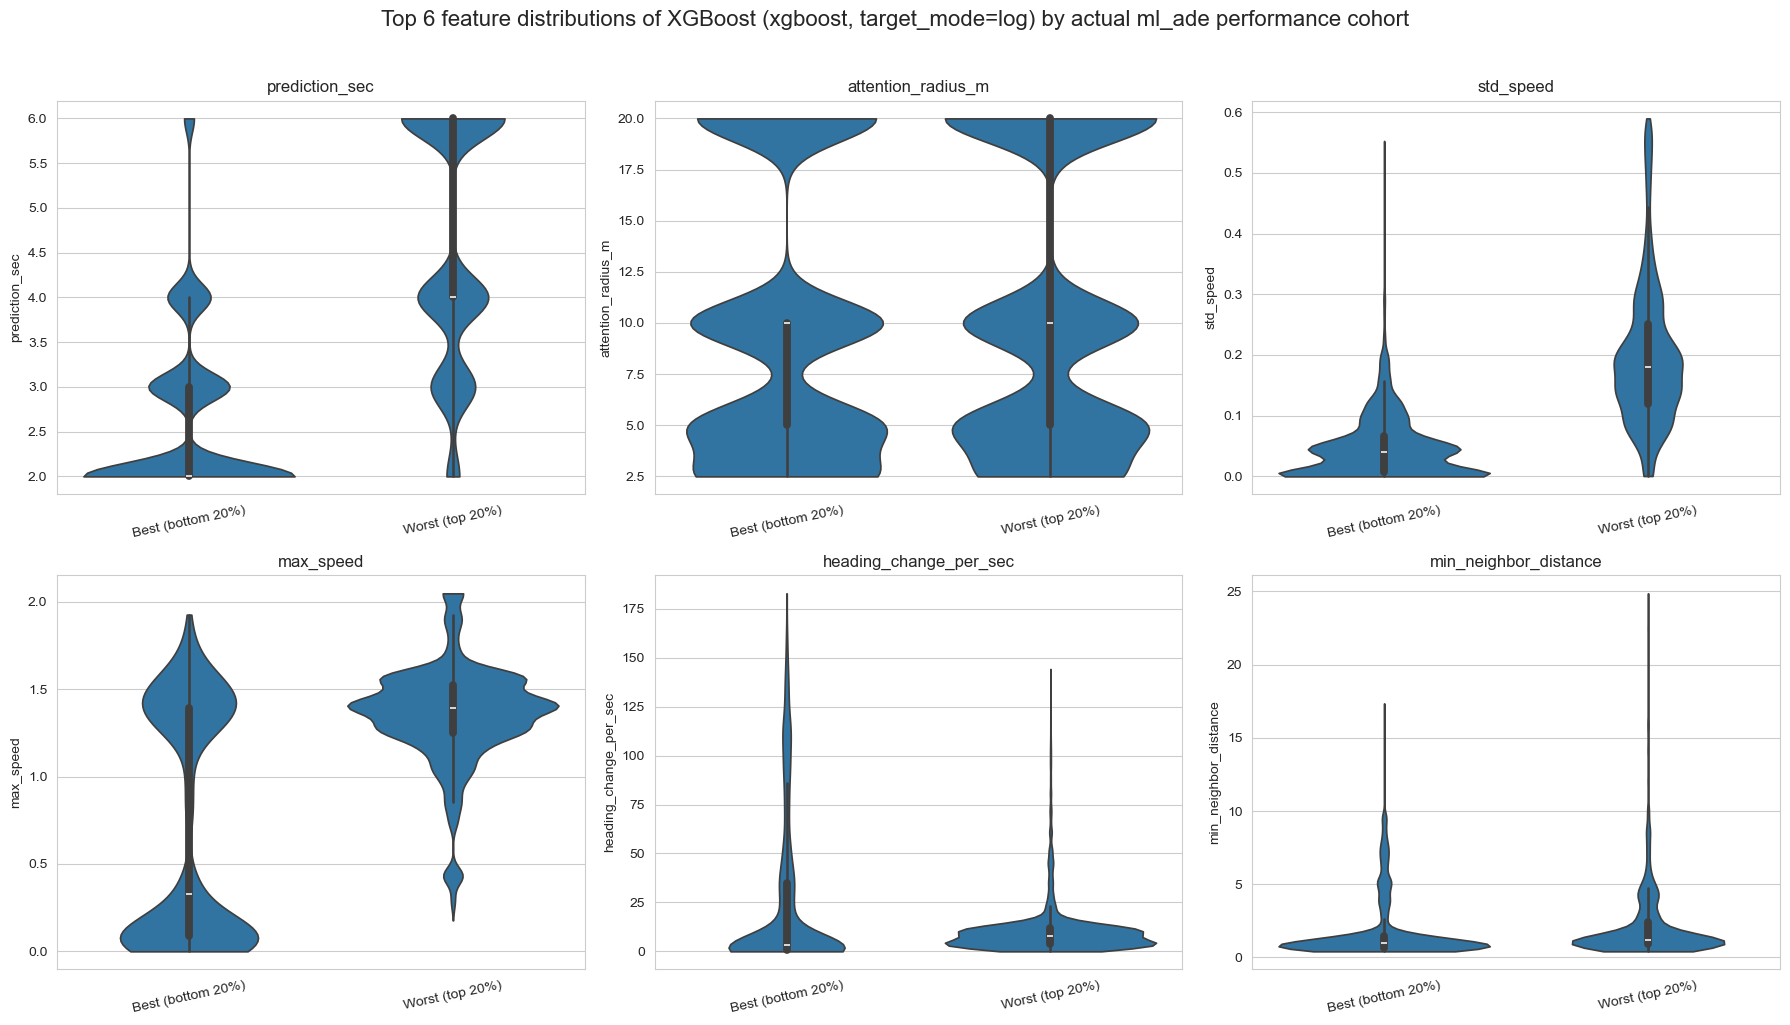

Actual metric used for cohorting: ml_ade
Best cohort size: 7390
Worst cohort size: 7390
Best threshold: 0.098174
Worst threshold: 0.570110
Cohort violin plot path: <repo>/results/interpretable_model/xgboost/sweep_large_30ep_1seed_MI_corrected/plots/cohort_violin_top_features_actual_ml_ade.png


In [53]:
# Cohorts are defined on the actual target, not the prediction, so the comparison stays
# anchored to observed performance instead of (interpretable)model self-assessment.
actual_metric_col = manifest.get(
    "raw_target_col", target_col[:-4] if target_col.endswith("_log") else target_col
)
actual_metric = model_df_oof["target_orig"].to_numpy()
poor_well_quantile = manifest.get("analysis", {}).get("poor_well_quantile", 0.20)

if LOWER_IS_BETTER:
    best_threshold = np.quantile(actual_metric, poor_well_quantile)
    worst_threshold = np.quantile(actual_metric, 1.0 - poor_well_quantile)
    best_mask = actual_metric <= best_threshold
    worst_mask = actual_metric >= worst_threshold
    best_label = f"Best (bottom {poor_well_quantile:.0%})"
    worst_label = f"Worst (top {poor_well_quantile:.0%})"
else:
    best_threshold = np.quantile(actual_metric, 1.0 - poor_well_quantile)
    worst_threshold = np.quantile(actual_metric, poor_well_quantile)
    best_mask = actual_metric >= best_threshold
    worst_mask = actual_metric <= worst_threshold
    best_label = f"Best (top {poor_well_quantile:.0%})"
    worst_label = f"Worst (bottom {poor_well_quantile:.0%})"

top_violin_features = ranked_features[:6]
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = np.array(axes).reshape(-1)

for ax, feat in zip(axes, top_violin_features):
    long_df = pd.concat(
        [
            pd.DataFrame(
                {"cohort": best_label, "value": X.loc[best_mask, feat].values}
            ),
            pd.DataFrame(
                {"cohort": worst_label, "value": X.loc[worst_mask, feat].values}
            ),
        ],
        ignore_index=True,
    )

    sns.violinplot(data=long_df, x="cohort", y="value", ax=ax, inner="box", cut=0)
    ax.set_title(feat)
    ax.set_xlabel("")
    ax.set_ylabel(feat)
    ax.tick_params(axis="x", rotation=12)

for ax in axes[len(top_violin_features) :]:
    ax.set_visible(False)

plt.suptitle(
    f"Top 6 feature distributions of {exported_model_label} by actual {actual_metric_col} performance cohort",
    fontsize=16,
    y=1.02,
)
plt.tight_layout()
cohort_plot_path = (
    PLOTS_DIR / f"cohort_violin_top_features_actual_{actual_metric_col}.png"
)
plt.savefig(cohort_plot_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Actual metric used for cohorting: {actual_metric_col}")
print(f"Best cohort size: {best_mask.sum()}")
print(f"Worst cohort size: {worst_mask.sum()}")
print(f"Best threshold: {best_threshold:.6f}")
print(f"Worst threshold: {worst_threshold:.6f}")
print(f"Cohort violin plot path: {cohort_plot_path}")

## 6. Saved Artifacts
**Purpose:** Summarize every artifact produced or consumed by this analysis run.<br>
**Inputs:** saved table/plot paths and the resolved run metadata.<br>
**Outputs:** a compact audit trail of manifest, model, tuning summary, and generated analysis artifacts.<br>
**How to Verify:** confirm each printed path exists and refers to the same run id selected at the top of the notebook.


In [54]:
print("Saved artifacts:")
print(f"- Run manifest:                 {manifest_path}")
print(f"- Final model:                  {model_path}")
print(f"- Tuning summary:               {full_data_tuning_summary_path}")
print(f"- Feature-effect ranking table: {importance_table_path}")
print(f"- Feature-effect table:         {feature_effect_table_path}")
print(f"- Feature-effect plot:          {importance_plot_path}")
print(f"- Effect plot grid:             {effect_plot_path}")
if effect_plot_mult_path is not None:
    print(f"- Effect plot grid (mult):      {effect_plot_mult_path}")
if interaction_plot_path is not None:
    print(f"- PDP interaction grid:         {interaction_plot_path}")
if interaction_plot_mult_path is not None:
    print(f"- PDP interaction grid (mult):  {interaction_plot_mult_path}")
print(f"- Cohort violin plot:           {cohort_plot_path}")
print(f"- Winning variant ID:           {winning_variant_model_id}")
if winning_variant_manifest_path is not None:
    print(f"- Winning variant manifest:     {winning_variant_manifest_path}")
if MODEL_ID == "xgboost":
    print(f"- SHAP beeswarm:                {beeswarm_path}")
if MODEL_ID == "gam":
    print(f"- Scaler:                       {scaler_path}")
print(f"- Plot directory:               {PLOTS_DIR}")

Saved artifacts:
- Run manifest:                 <repo>/results/interpretable_model/xgboost/sweep_large_30ep_1seed_MI_corrected/tables/run_manifest_ml_ade_log.json
- Final model:                  <repo>/results/interpretable_model/xgboost/sweep_large_30ep_1seed_MI_corrected/xgb_model_ml_ade_log.json
- Tuning summary:               <repo>/results/interpretable_model/xgboost/sweep_large_30ep_1seed_MI_corrected/tables/full_data_tuning_optuna_summary_ml_ade_log.json
- Feature-effect ranking table: <repo>/results/interpretable_model/xgboost/sweep_large_30ep_1seed_MI_corrected/tables/feature_effect_importance_ml_ade_log.csv
- Feature-effect table:         <repo>/results/interpretable_model/xgboost/sweep_large_30ep_1seed_MI_corrected/tables/feature_effects_ml_ade_log.csv
- Feature-effect plot:          <repo>/results/interpretable_model/xgboost/sweep_large_30ep_1seed_MI_corrected/plots/feature_effect_importance_ml_ade_log.png
- Effect plot grid:             <repo>/results/interpretable_model/